# Aktivnost 3 - analiza i priprema podataka

**Tema:** Predikcija cena nekretnina primenom metoda masinskog ucenja  
**Cilj:** eksplorativna analiza, ciscenje duplikata i outlier-a, vizualizacije pre/posle ciscenja i priprema preprocessing pipeline-a.


In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data" / "nekretnine_raw.csv").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent


def extract_total_floors(raw_text):
    totals = re.findall(r"/\s*(-?\d+(?:[\.,]\d+)?)", raw_text)
    if totals:
        return float(totals[0].replace(",", "."))
    return np.nan


def parse_floor_values(raw_floor_string):
    raw = "" if pd.isna(raw_floor_string) else str(raw_floor_string).strip().lower()
    if not raw or raw in {"nepoznato", "-"}:
        return np.nan, np.nan

    if "suteren" in raw:
        return -1.0, extract_total_floors(raw)

    if "visoko prizemlje" in raw or "prizemlje" in raw:
        return 0.0, extract_total_floors(raw)

    match = re.search(r"(-?\d+(?:[\.,]\d+)?)\s*/\s*(-?\d+(?:[\.,]\d+)?)", raw)
    if match:
        floor = float(match.group(1).replace(",", "."))
        total = float(match.group(2).replace(",", "."))
        return floor, total

    number_match = re.search(r"^-?\d+(?:[\.,]\d+)?$", raw)
    if number_match:
        return float(raw.replace(",", ".")), np.nan

    return np.nan, np.nan


sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 80)

## Ucitavanje podataka

Analiza koristi korigovani fajl `data/nekretnine_raw.csv`. Svaki red predstavlja jedan oglas za prodaju nekretnine.


In [2]:
DATA_PATH = PROJECT_ROOT / "data" / "nekretnine_raw.csv"  # data/nekretnine_raw.csv
raw_df = pd.read_csv(DATA_PATH)

print(f"Broj redova: {raw_df.shape[0]:,}".replace(",", "."))
print(f"Broj kolona: {raw_df.shape[1]}")
display(raw_df.head())
display(raw_df.dtypes.rename("dtype").to_frame())

Broj redova: 20.584
Broj kolona: 13


,title,description,area_m2,price_eur,city,region,street,heating_type,rooms,parking,raw_floor_string,year_built,url
0,"Zvezdara, Crveni krst - Golubačka, 102m2, Golu...","Zvezdara, Crveni krst - Golubačka 4.0, 102m2 (...",102.0,450000.0,Beograd,Crveni krst,Golubačka,Centralno,4.0,Da,3 / 5,2007.0,https://www.nekretnine.rs/stambeni-objekti/sta...
1,"Stari grad, Skadarlija - Bulevar despota Stefa...","Stari grad, Skadarlija - Bulevar despota Stefa...",77.0,296000.0,Beograd,Skadarlija,Bulevar despota Stefana,Etažno,4.0,Ne,2 / 4,1929.0,https://www.nekretnine.rs/stambeni-objekti/sta...
2,"Zvezdara, Mirijevo - Kapetana Miloša Žunjića, ...","Zvezdara, Mirijevo - Kapetana Miloša Žunjića 3...",70.0,204000.0,Beograd,Mirijevo I,Kapetana Miloša Žunjića,Centralno,3.0,Ne,1 / 4,2011.0,https://www.nekretnine.rs/stambeni-objekti/sta...
3,"Zvezdara, Vukov spomenik - Luke Vukalovića, 92...","Zvezdara, Vukov spomenik - Luke Vukalovića 3.5...",92.0,420000.0,Beograd,Vukov spomenik,Luke Vukalovića,Podno,3.0,Da,8 / 8,2024.0,https://www.nekretnine.rs/stambeni-objekti/sta...
4,"Vračar, centar - Resavska, 86m2, Resavska","Vračar, centar - Resavska 3.0, 86m2 (lođa 3m2)...",86.0,320000.0,Beograd,Vračar (Centar),Resavska,Centralno,3.0,Ne,2 / 3,1938.0,https://www.nekretnine.rs/stambeni-objekti/sta...


,dtype
title,object
description,object
area_m2,float64
price_eur,float64
city,object
region,object
street,object
heating_type,object
rooms,float64
parking,object


## Pocetna EDA

Pre ciscenja proveravamo nedostajuce vrednosti, tacne duplikate, duplirane URL-ove i osnovne statistike numerickih kolona.


In [3]:
missing_table = pd.DataFrame(
    {
        "missing_count": raw_df.isna().sum(),
        "missing_pct": (raw_df.isna().mean() * 100).round(2),
    }
).sort_values("missing_count", ascending=False)

print("Tacni duplirani redovi:", int(raw_df.duplicated().sum()))
print("Duplirani URL-ovi:", int(raw_df["url"].duplicated().sum()))
display(missing_table)
display(
    raw_df[["area_m2", "price_eur", "rooms", "year_built"]]
    .describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])
    .round(2)
)

Tacni duplirani redovi: 0
Duplirani URL-ovi: 0


,missing_count,missing_pct
year_built,15923,77.36
rooms,2868,13.93
price_eur,147,0.71
area_m2,73,0.35
description,32,0.16
title,19,0.09
street,2,0.01
city,0,0.00
region,0,0.00
heating_type,0,0.00


,area_m2,price_eur,rooms,year_built
count,20511.00,20437.00,17716.00,4661.00
mean,145.45,213106.74,2.99,2003.28
std,5832.90,206836.31,3.03,318.82
min,-80.00,1.00,-3.00,-2021.00
1%,21.00,39517.28,0.00,1924.00
5%,28.00,61800.00,1.00,1960.00
50%,62.00,158164.00,3.00,2024.00
95%,156.00,535000.00,5.00,2027.00
99%,359.80,1041000.00,15.00,2028.00
max,569284.00,7500000.00,45.00,20206.00


## Composite key duplikati

Tacni duplikati i URL nisu dovoljni za oglase koji su ponovljeni pod razlicitim adresama. Zato koristimo kompozitni kljuc `title + description + area_m2 + price_eur + city` i deduplikujemo samo redove kojima su sve komponente kljuca poznate.


In [5]:
composite_primary_key = ["title", "description", "area_m2", "price_eur", "city"]

complete_key_df = raw_df.dropna(subset=composite_primary_key).copy()
incomplete_key_df = raw_df[raw_df[composite_primary_key].isna().any(axis=1)].copy()

composite_duplicate_rows_df = complete_key_df[
    complete_key_df.duplicated(subset=composite_primary_key, keep=False)
].copy()
composite_duplicate_rows = len(composite_duplicate_rows_df)
composite_duplicate_groups = composite_duplicate_rows_df.groupby(
    composite_primary_key, dropna=False
).size()
rows_removed_if_keeping_first = int(
    complete_key_df.duplicated(subset=composite_primary_key, keep="first").sum()
)

deduped_complete_df = complete_key_df.drop_duplicates(
    subset=composite_primary_key, keep="first"
)
deduped_df = pd.concat([deduped_complete_df, incomplete_key_df], ignore_index=True)

duplicate_summary = pd.DataFrame(
    [
        {"metrika": "Redovi u raw_df", "vrednost": len(raw_df)},
        {
            "metrika": "Redovi sa kompletnim composite key",
            "vrednost": len(complete_key_df),
        },
        {"metrika": "composite_duplicate_rows", "vrednost": composite_duplicate_rows},
        {
            "metrika": "Grupe composite key duplikata",
            "vrednost": len(composite_duplicate_groups),
        },
        {
            "metrika": "rows_removed_if_keeping_first",
            "vrednost": rows_removed_if_keeping_first,
        },
        {"metrika": "Redovi u deduped_df", "vrednost": len(deduped_df)},
    ]
)

top_duplicate_groups = (
    composite_duplicate_groups.sort_values(ascending=False)
    .head(10)
    .rename("group_size")
    .reset_index()
)

display(duplicate_summary)
display(top_duplicate_groups)

,metrika,vrednost
0,Redovi u raw_df,20584
1,Redovi sa kompletnim composite key,20379
2,composite_duplicate_rows,1357
3,Grupe composite key duplikata,498
4,rows_removed_if_keeping_first,859
5,Redovi u deduped_df,19725


,title,description,area_m2,price_eur,city,group_size
0,"Novogradnja na Panteleju, 2.5, 61.17 m2",Na prodaju dvoiposoban stan u novogradnji na P...,63.18,116890.0,Niš,6
1,3.5 Vagres Sity,"Na prodaju nov, neuseljavan troiposoban stan n...",99.00,170000.0,Niš,6
2,Predstavljamo vam odličan porodičan stan na sa...,Predstavljamo vam odličan porodičan stan na sa...,71.00,138950.0,Futog,4
3,LUX NOVOGRADNJA SA GRAĐEVINSKOM DOZVOLOM,SMART ZGRADE JEDINSTVENE U BEOGRADU https://sm...,57.00,156750.0,Beograd,4
4,Troiposoban stan u izgradnji na Klisi-Mali Beo...,Predstavljamo vam pravi porodičan stan koji je...,71.00,131140.0,Novi Sad,4
5,Odličan dvosoban stan na Novoj Detelinari,Na prodaju komforan dvosoban stan u najlepšem ...,64.00,185400.0,Novi Sad,4
6,NOVOGRADNJA SA PAMETNIM STANOVIMA,SMART ZGRADE – JEDINSTVENE U BEOGRADU https://...,44.00,115000.0,Beograd,4
7,"Novogradnja, Mokranjčeva","Na prodaju stan u novogradnji u Mokranjčevoj, ...",47.22,89720.0,Niš,3
8,"Novogradnja, Mokranjčeva","Na prodaju stan u novogradnji u Mokranjčevoj, ...",46.95,89210.0,Niš,3
9,"Novogradnja, Mokranjčeva","Na prodaju stan u novogradnji u Mokranjčevoj, ...",46.82,88960.0,Niš,3


## Ciscenje outlier-a

Posle deduplikacije uklanjamo redove koji nisu pogodni za pocetno modelovanje: nevalidnu kvadraturu, cenu, broj soba i godinu izgradnje. Nedostajuce vrednosti za `rooms` i `year_built` se zadrzavaju jer mogu kasnije da se imputiraju.


In [6]:
valid_area = deduped_df["area_m2"].between(10, 500)
valid_price = deduped_df["price_eur"].between(10_000, 1_000_000)
valid_rooms = deduped_df["rooms"].isna() | deduped_df["rooms"].between(0.5, 10)
valid_year = deduped_df["year_built"].isna() | deduped_df["year_built"].between(
    1800, 2028
)
valid_model_rows = valid_area & valid_price & valid_rooms & valid_year

cleaned_df = deduped_df[valid_model_rows].copy()
cleaned_df["price_per_m2"] = (cleaned_df["price_eur"] / cleaned_df["area_m2"]).round(2)

before_after_summary = pd.DataFrame(
    [
        {"faza": "Pre ciscenja", "redovi": len(raw_df)},
        {"faza": "Posle composite key deduplikacije", "redovi": len(deduped_df)},
        {"faza": "Posle ciscenja", "redovi": len(cleaned_df)},
    ]
)
before_after_summary["uklonjeno_u_odnosu_na_prethodnu_fazu"] = (
    before_after_summary["redovi"]
    .shift(1)
    .sub(before_after_summary["redovi"])
    .fillna(0)
    .astype(int)
)

outlier_summary = pd.DataFrame(
    [
        {
            "pravilo": "area_m2 van opsega 10-500 ili nedostaje",
            "broj_redova": int((~valid_area).sum()),
        },
        {
            "pravilo": "price_eur van opsega 10.000-1.000.000 ili nedostaje",
            "broj_redova": int((~valid_price).sum()),
        },
        {
            "pravilo": "rooms van opsega 0.5-10 kada postoji",
            "broj_redova": int((~valid_rooms).sum()),
        },
        {
            "pravilo": "year_built van opsega 1800-2028 kada postoji",
            "broj_redova": int((~valid_year).sum()),
        },
        {
            "pravilo": "ukupno uklonjeno posle deduplikacije",
            "broj_redova": int((~valid_model_rows).sum()),
        },
    ]
)

outlier_examples = deduped_df.loc[
    ~valid_model_rows,
    ["title", "area_m2", "price_eur", "rooms", "year_built", "city", "region", "url"],
].copy()
outlier_examples = outlier_examples.sort_values(
    ["price_eur", "area_m2"], ascending=False
).head(12)

display(before_after_summary)
display(outlier_summary)
display(outlier_examples)

,faza,redovi,uklonjeno_u_odnosu_na_prethodnu_fazu
0,Pre ciscenja,20584,0
1,Posle composite key deduplikacije,19725,859
2,Posle ciscenja,18651,1074


,pravilo,broj_redova
0,area_m2 van opsega 10-500 ili nedostaje,95
1,price_eur van opsega 10.000-1.000.000 ili nedo...,442
2,rooms van opsega 0.5-10 kada postoji,561
3,year_built van opsega 1800-2028 kada postoji,38
4,ukupno uklonjeno posle deduplikacije,1074


,title,area_m2,price_eur,rooms,year_built,city,region,url
9326,"Poslovna zgrada, centar",2927.00,7500000.0,8.0,NaN,Beograd,Zeleni venac,https://www.nekretnine.rs/stambeni-objekti/sta...
19326,- crna gora sf 2680,13000.00,5500000.0,10.0,NaN,Kotor,Nepoznato,https://www.nekretnine.rs/stambeni-objekti/sta...
15011,Spektakularan Penthouse sa pogledom na ceo Grad,453.19,5000000.0,5.0,NaN,Beograd,Novi Beograd Blok 65,https://www.nekretnine.rs/stambeni-objekti/sta...
6051,Vrhunski kvalitet !,131.00,3711100.0,5.0,NaN,Novi Sad,Grbavica,https://www.nekretnine.rs/stambeni-objekti/sta...
6044,Stan sa benefitima !!,156.00,3374330.0,45.0,NaN,Petrovaradin,Stari majur,https://www.nekretnine.rs/stambeni-objekti/sta...
14789,BW RESIDENCES -Lux stan sa fantastičnim pogledom,342.42,2800000.0,5.0,NaN,Beograd,Beograd na vodi,https://www.nekretnine.rs/stambeni-objekti/sta...
18934,NOVI STAMBENI KOMPLEKS U VRNJACKOJ BANJI,1977.00,2640000.0,NaN,NaN,Vrnjačka Banja,Širi centar,https://www.nekretnine.rs/stambeni-objekti/sta...
13399,"#31228, Prodaja, Stan, KRUNSKA, 2600000 EUR",392.00,2600000.0,5.0,NaN,Beograd,Vračar (Centar),https://www.nekretnine.rs/stambeni-objekti/sta...
14459,"3.0, Ada mall, Karpoševa, 69.45, 3/4, toplotne...",69.45,2430075.0,3.0,NaN,Beograd,Banovo brdo,https://www.nekretnine.rs/stambeni-objekti/sta...
961,Četvorosoban stan na Limanu 4!!,92.00,2396900.0,NaN,NaN,Novi Sad,Liman 4,https://www.nekretnine.rs/stambeni-objekti/sta...


## Distribucije pre i posle ciscenja

Grafici prikazuju kako deduplikacija i outlier filter menjaju raspodelu cena i kvadrature. Cene su prikazane u hiljadama EUR radi citljivosti.


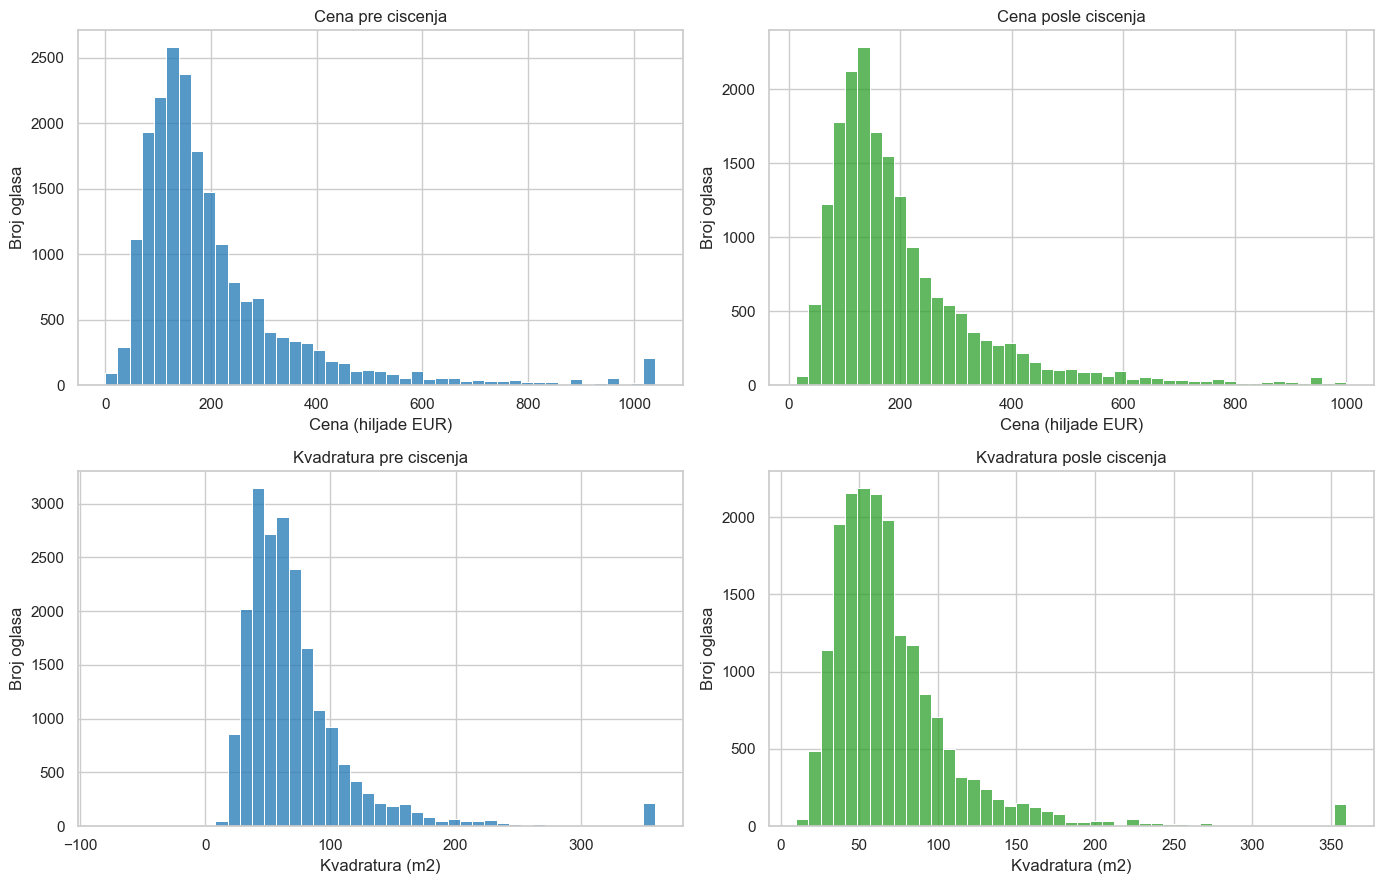

In [7]:
price_upper = raw_df["price_eur"].quantile(0.99)
area_upper = raw_df["area_m2"].quantile(0.99)

raw_price_plot = raw_df["price_eur"].dropna().clip(upper=price_upper) / 1000
cleaned_price_plot = cleaned_df["price_eur"].dropna().clip(upper=price_upper) / 1000
raw_area_plot = raw_df["area_m2"].dropna().clip(upper=area_upper)
cleaned_area_plot = cleaned_df["area_m2"].dropna().clip(upper=area_upper)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
sns.histplot(raw_price_plot, bins=45, color="tab:blue", ax=axes[0, 0])
axes[0, 0].set_title("Cena pre ciscenja")
axes[0, 0].set_xlabel("Cena (hiljade EUR)")
axes[0, 0].set_ylabel("Broj oglasa")

sns.histplot(cleaned_price_plot, bins=45, color="tab:green", ax=axes[0, 1])
axes[0, 1].set_title("Cena posle ciscenja")
axes[0, 1].set_xlabel("Cena (hiljade EUR)")
axes[0, 1].set_ylabel("Broj oglasa")

sns.histplot(raw_area_plot, bins=45, color="tab:blue", ax=axes[1, 0])
axes[1, 0].set_title("Kvadratura pre ciscenja")
axes[1, 0].set_xlabel("Kvadratura (m2)")
axes[1, 0].set_ylabel("Broj oglasa")

sns.histplot(cleaned_area_plot, bins=45, color="tab:green", ax=axes[1, 1])
axes[1, 1].set_title("Kvadratura posle ciscenja")
axes[1, 1].set_xlabel("Kvadratura (m2)")
axes[1, 1].set_ylabel("Broj oglasa")

plt.tight_layout()

## Kategoricke raspodele

Uporedjujemo najcesce gradove pre ciscenja i posle ciscenja, jer je najvise oglasa koncentrisano u nekoliko vecih trzista.


,Pre ciscenja,Posle ciscenja,uklonjeno
city,,,
Beograd,8110,7690,420
Novi Sad,7293,6817,476
Niš,1904,1172,732
Zlatibor,433,398,35
Petrovaradin,274,247,27
Stara Pazova,240,234,6
Pančevo,238,230,8
Vrnjačka Banja,214,187,27
Jagodina,203,182,21


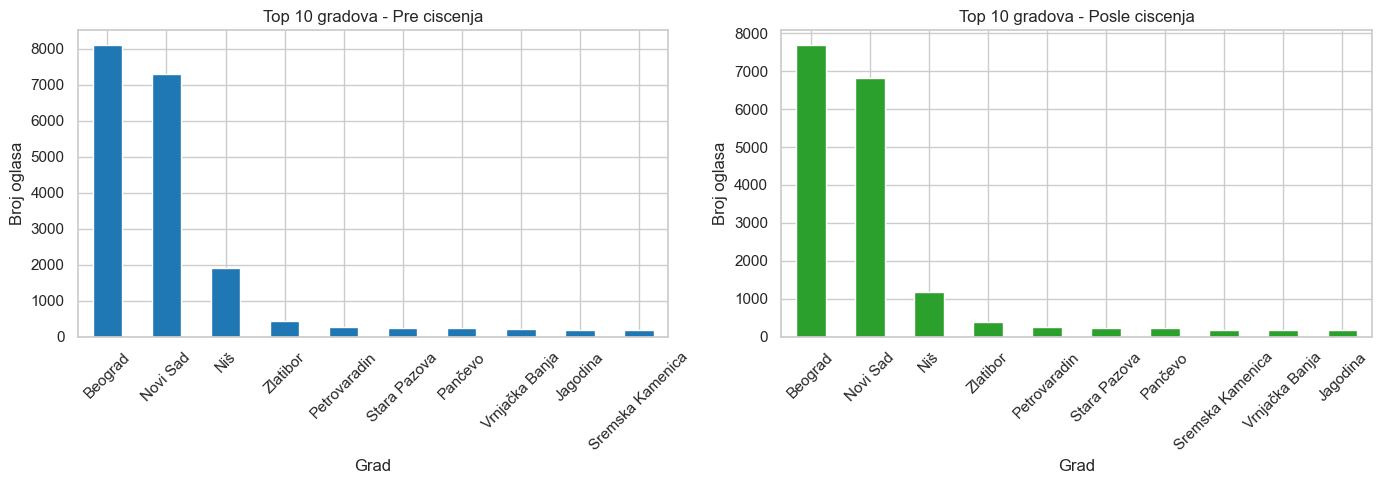

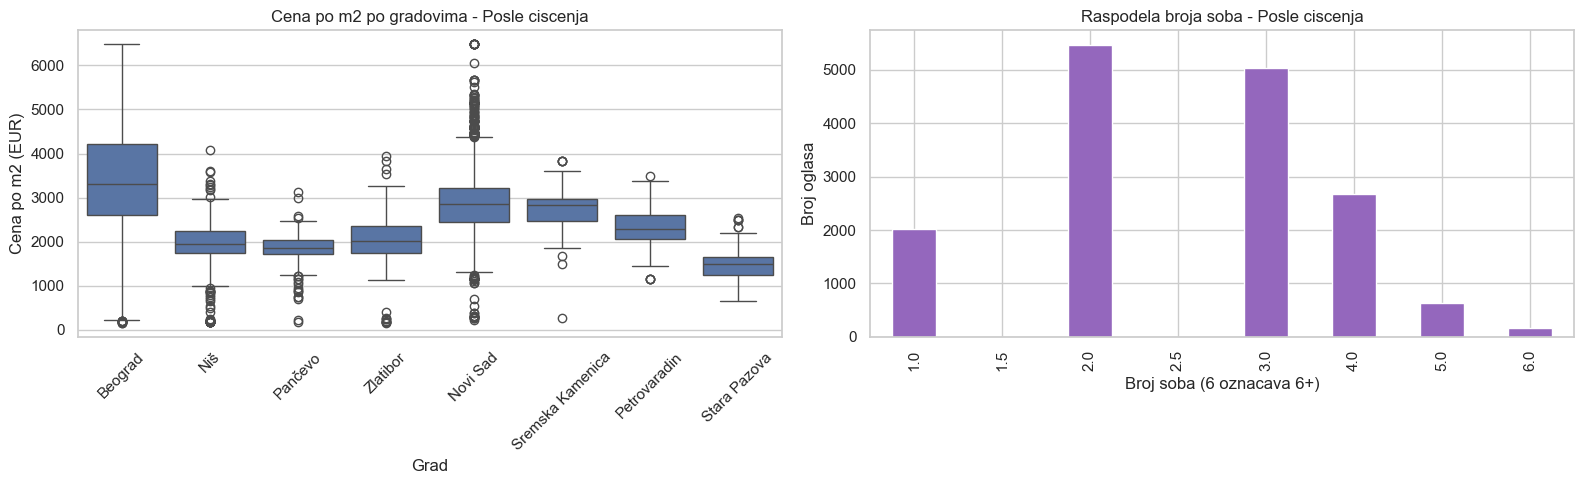

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

raw_df["city"].value_counts().head(10).plot(kind="bar", ax=axes[0], color="tab:blue")
axes[0].set_title("Top 10 gradova - Pre ciscenja")
axes[0].set_xlabel("Grad")
axes[0].set_ylabel("Broj oglasa")
axes[0].tick_params(axis="x", rotation=45)

cleaned_df["city"].value_counts().head(10).plot(
    kind="bar", ax=axes[1], color="tab:green"
)
axes[1].set_title("Top 10 gradova - Posle ciscenja")
axes[1].set_xlabel("Grad")
axes[1].set_ylabel("Broj oglasa")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()

city_before_after = (
    pd.DataFrame(
        {
            "Pre ciscenja": raw_df["city"].value_counts(),
            "Posle ciscenja": cleaned_df["city"].value_counts(),
        }
    )
    .fillna(0)
    .astype(int)
)
city_before_after["uklonjeno"] = (
    city_before_after["Pre ciscenja"] - city_before_after["Posle ciscenja"]
)
display(city_before_after.sort_values("Pre ciscenja", ascending=False).head(10))

top_cleaned_cities = cleaned_df["city"].value_counts().head(8).index
price_per_m2_by_city = cleaned_df[cleaned_df["city"].isin(top_cleaned_cities)].copy()
price_per_m2_by_city["price_per_m2_plot"] = price_per_m2_by_city["price_per_m2"].clip(
    upper=price_per_m2_by_city["price_per_m2"].quantile(0.99)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.boxplot(data=price_per_m2_by_city, x="city", y="price_per_m2_plot", ax=axes[0])
axes[0].set_title("Cena po m2 po gradovima - Posle ciscenja")
axes[0].set_xlabel("Grad")
axes[0].set_ylabel("Cena po m2 (EUR)")
axes[0].tick_params(axis="x", rotation=45)

cleaned_df["rooms"].dropna().clip(upper=6).value_counts().sort_index().plot(
    kind="bar", ax=axes[1], color="tab:purple"
)
axes[1].set_title("Raspodela broja soba - Posle ciscenja")
axes[1].set_xlabel("Broj soba (6 oznacava 6+)")
axes[1].set_ylabel("Broj oglasa")

plt.tight_layout()

## Procentualni prikaz oglasa

Prikazujemo koliko oglasa svaki od gradova zauzima u procentima


In [ ]:
city_percentages = (cleaned_df["city"].value_counts((normalize = True)) * 100)
  .round(2)
  .rename("Procenat (%)")
  .to_frame();
city_percentages["Broj oglasa"] = cleaned_df["city"].value_counts();
display(city_percentages.head(15));


,Procenat (%),Broj oglasa
city,,
Beograd,41.23,7690
Novi Sad,36.55,6817
Niš,6.28,1172
Zlatibor,2.13,398
Petrovaradin,1.32,247
Stara Pazova,1.25,234
Pančevo,1.23,230
Sremska Kamenica,1.01,189
Vrnjačka Banja,1.00,187


## Analiza cena po regionima

Prikazujemo distribuciju cena za top 10 regiona u Beogradu i Novom Sadu koristeći candlestick format (5%, 25%, Median, 75%, 95% percentili).


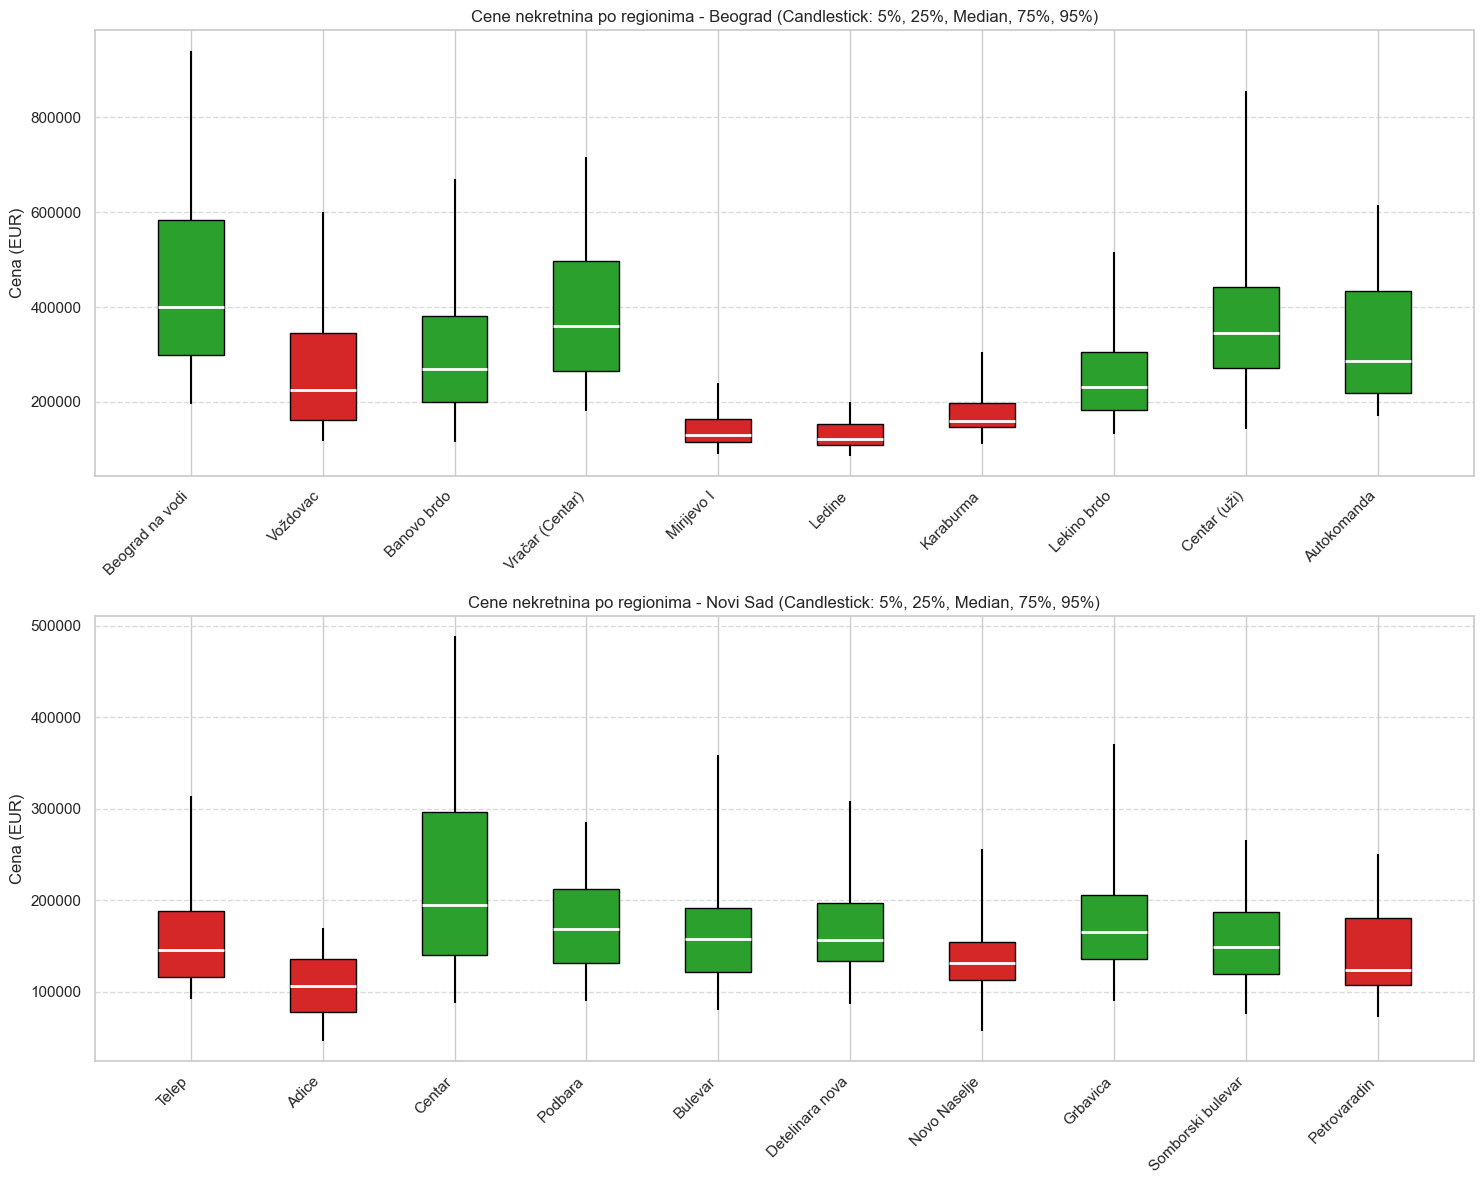

In [ ]:
# Analiza regiona za Beograd i Novi Sad
bg_df = cleaned_df[cleaned_df["city"] == "Beograd"]
ns_df = cleaned_df[cleaned_df["city"] == "Novi Sad"]

# Top 10 regiona po broju oglasa za svaki grad
top_bg_regions = bg_df["region"].value_counts().head(10).index
top_ns_regions = ns_df["region"].value_counts().head(10).index


def plot_candlestick_prices(ax, df, regions, title):
    for i, region in enumerate(regions):
        subset = df[df["region"] == region]["price_eur"]
        if len(subset) == 0:
            continue

        low, q1, med, q3, high = np.percentile(subset, [5, 25, 50, 75, 95])

        # Boja: zelena ako je medijan iznad medijana grada, crvena ako je ispod
        city_med = df["price_eur"].median()
        color = "tab:green" if med >= city_med else "tab:red"

        # Fitilj (High-Low)
        ax.vlines(i, low, high, color="black", lw=1.5)
        # Telo (Q1-Q3)
        ax.add_patch(
            plt.Rectangle(
                (i - 0.25, q1),
                0.5,
                q3 - q1,
                facecolor=color,
                edgecolor="black",
                zorder=3,
            )
        )
        # Medijan (bela linija)
        ax.hlines(med, i - 0.25, i + 0.25, color="white", lw=2, zorder=4)

    ax.set_xticks(range(len(regions)))
    ax.set_xticklabels(regions, rotation=45, ha="right")
    ax.set_title(title)
    ax.set_ylabel("Cena (EUR)")
    ax.grid(True, axis="y", linestyle="--", alpha=0.7)


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))

plot_candlestick_prices(
    ax1,
    bg_df,
    top_bg_regions,
    "Cene nekretnina po regionima - Beograd (Candlestick: 5%, 25%, Median, 75%, 95%)",
)
plot_candlestick_prices(
    ax2,
    ns_df,
    top_ns_regions,
    "Cene nekretnina po regionima - Novi Sad (Candlestick: 5%, 25%, Median, 75%, 95%)",
)

plt.tight_layout()
plt.show()

## Korelacije

Raw Pearson korelacija cene i kvadrature je osetljiva na ekstremne vrednosti. Zato poredimo raw i cleaned korelacije i prikazujemo korelacionu matricu na `cleaned_df`.


,area_price_correlation
metrika,
Pearson raw_df,0.003
Spearman raw_df,0.736
Pearson cleaned_df,0.527
Spearman cleaned_df,0.744


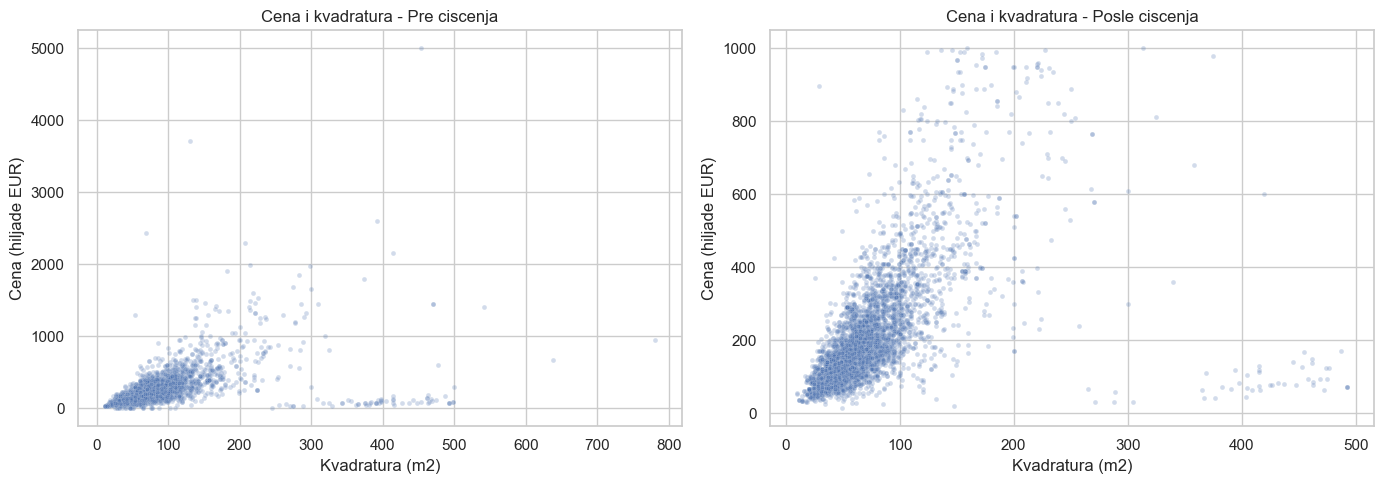

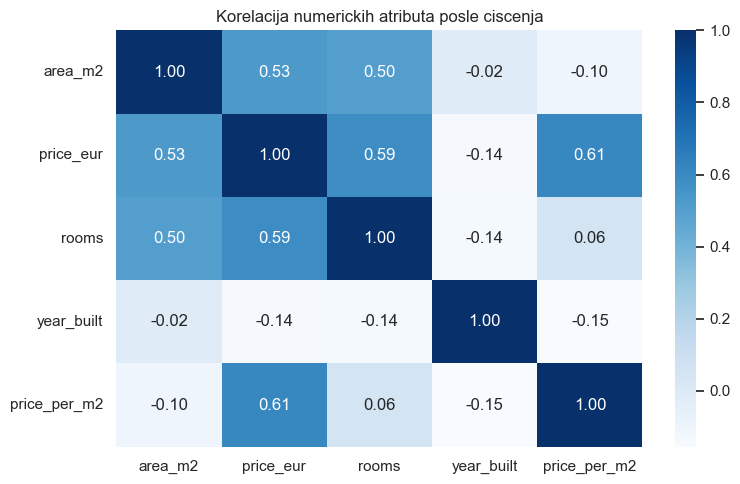

In [11]:
raw_correlation_df = raw_df[["area_m2", "price_eur"]].dropna()
cleaned_correlation_df = cleaned_df[["area_m2", "price_eur"]].dropna()

correlation_comparison = pd.DataFrame(
    [
        {
            "metrika": "Pearson raw_df",
            "area_price_correlation": raw_correlation_df["area_m2"].corr(
                raw_correlation_df["price_eur"], method="pearson"
            ),
        },
        {
            "metrika": "Spearman raw_df",
            "area_price_correlation": raw_correlation_df["area_m2"].corr(
                raw_correlation_df["price_eur"], method="spearman"
            ),
        },
        {
            "metrika": "Pearson cleaned_df",
            "area_price_correlation": cleaned_correlation_df["area_m2"].corr(
                cleaned_correlation_df["price_eur"], method="pearson"
            ),
        },
        {
            "metrika": "Spearman cleaned_df",
            "area_price_correlation": cleaned_correlation_df["area_m2"].corr(
                cleaned_correlation_df["price_eur"], method="spearman"
            ),
        },
    ]
).set_index("metrika")
display(correlation_comparison.round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
scatter_raw = (
    raw_df[["area_m2", "price_eur"]]
    .dropna()
    .sample(
        min(5000, raw_df[["area_m2", "price_eur"]].dropna().shape[0]), random_state=42
    )
)
scatter_cleaned = (
    cleaned_df[["area_m2", "price_eur"]]
    .dropna()
    .sample(
        min(5000, cleaned_df[["area_m2", "price_eur"]].dropna().shape[0]),
        random_state=42,
    )
)

sns.scatterplot(
    data=scatter_raw,
    x="area_m2",
    y=scatter_raw["price_eur"] / 1000,
    alpha=0.25,
    s=12,
    ax=axes[0],
)
axes[0].set_title("Cena i kvadratura - Pre ciscenja")
axes[0].set_xlabel("Kvadratura (m2)")
axes[0].set_ylabel("Cena (hiljade EUR)")

sns.scatterplot(
    data=scatter_cleaned,
    x="area_m2",
    y=scatter_cleaned["price_eur"] / 1000,
    alpha=0.25,
    s=12,
    ax=axes[1],
)
axes[1].set_title("Cena i kvadratura - Posle ciscenja")
axes[1].set_xlabel("Kvadratura (m2)")
axes[1].set_ylabel("Cena (hiljade EUR)")
plt.tight_layout()

plt.figure(figsize=(8, 5))
sns.heatmap(
    cleaned_df[["area_m2", "price_eur", "rooms", "year_built", "price_per_m2"]].corr(),
    annot=True,
    cmap="Blues",
    fmt=".2f",
)
plt.title("Korelacija numerickih atributa posle ciscenja")
plt.tight_layout()

## Preprocessing za modelovanje

Na `cleaned_df` formiramo izvedene atribute i `ColumnTransformer` pipeline za narednu aktivnost.


In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

model_df = cleaned_df.copy()

categorical_cols = [
    "city",
    "region",
    "street",
    "heating_type",
    "parking",
    "raw_floor_string",
]
for col in categorical_cols:
    model_df[col] = model_df[col].replace({"-": np.nan, "": np.nan})

floor_values = model_df["raw_floor_string"].apply(parse_floor_values)
model_df["floor"] = [value[0] for value in floor_values]
model_df["total_floors"] = [value[1] for value in floor_values]
model_df["is_last_floor"] = np.where(
    model_df["floor"].notna() & model_df["total_floors"].notna(),
    (model_df["floor"] == model_df["total_floors"]).astype(int),
    np.nan,
)

model_df["building_age"] = np.where(
    model_df["year_built"].notna(), 2026 - model_df["year_built"], np.nan
)
text = (
    model_df["title"].fillna("") + " " + model_df["description"].fillna("")
).str.lower()
model_df["is_lux"] = text.str.contains(r"\b(?:lux|luks)\b", regex=True).astype(int)
model_df["is_penthouse"] = text.str.contains(
    r"\b(?:penthouse|penthaus)\b", regex=True
).astype(int)
model_df["is_duplex"] = text.str.contains(r"\b(?:duplex|dupleks)\b", regex=True).astype(
    int
)

target = "price_eur"
numeric_features = [
    "area_m2",
    "rooms",
    "floor",
    "total_floors",
    "is_last_floor",
    "year_built",
    "building_age",
    "is_lux",
    "is_penthouse",
    "is_duplex",
]
categorical_features = ["city", "region", "heating_type", "parking"]

X = model_df[numeric_features + categorical_features]
y = model_df[target]

numeric_pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="constant", fill_value="Nepoznato")),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared = preprocessor.transform(X_test)


def transformed_missing_count(matrix):
    if hasattr(matrix, "toarray"):
        return int(np.isnan(matrix.data).sum())
    return int(np.isnan(matrix).sum())


preprocessing_summary = pd.DataFrame(
    [
        {
            "skup": "X_train",
            "redovi": X_train.shape[0],
            "kolone_pre": X_train.shape[1],
            "kolone_posle": X_train_prepared.shape[1],
            "missing_posle": transformed_missing_count(X_train_prepared),
        },
        {
            "skup": "X_test",
            "redovi": X_test.shape[0],
            "kolone_pre": X_test.shape[1],
            "kolone_posle": X_test_prepared.shape[1],
            "missing_posle": transformed_missing_count(X_test_prepared),
        },
    ]
)

print("Pre ciscenja:", raw_df.shape)
print("Posle ciscenja:", model_df.shape)
print("Train:", X_train.shape, "Test:", X_test.shape)
print(
    "Nedostajuce vrednosti posle preprocessinga:",
    int(preprocessing_summary["missing_posle"].sum()),
)
display(preprocessing_summary)
display(
    model_df[numeric_features + categorical_features + [target, "price_per_m2"]].head()
)

Pre ciscenja: (20584, 13)
Posle ciscenja: (18651, 21)
Train: (14920, 14) Test: (3731, 14)
Nedostajuce vrednosti posle preprocessinga: 0


,skup,redovi,kolone_pre,kolone_posle,missing_posle
0,X_train,14920,14,834,0
1,X_test,3731,14,834,0


,area_m2,rooms,floor,total_floors,is_last_floor,year_built,building_age,is_lux,is_penthouse,is_duplex,city,region,heating_type,parking,price_eur,price_per_m2
0,102.0,4.0,3.0,5.0,0.0,2007.0,19.0,0,0,0,Beograd,Crveni krst,Centralno,Da,450000.0,4411.76
1,77.0,4.0,2.0,4.0,0.0,1929.0,97.0,0,0,0,Beograd,Skadarlija,Etažno,Ne,296000.0,3844.16
2,70.0,3.0,1.0,4.0,0.0,2011.0,15.0,0,0,0,Beograd,Mirijevo I,Centralno,Ne,204000.0,2914.29
3,92.0,3.0,8.0,8.0,1.0,2024.0,2.0,0,1,0,Beograd,Vukov spomenik,Podno,Da,420000.0,4565.22
4,86.0,3.0,2.0,3.0,0.0,1938.0,88.0,0,0,0,Beograd,Vračar (Centar),Centralno,Ne,320000.0,3720.93
